In [1]:
import os
import sys
from pathlib import Path

import hydra
import rootutils
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from torchvision.transforms import v2
from omegaconf import OmegaConf

# Setup root directory
project_root = rootutils.setup_root(
    __file__ if "__file__" in dir() else os.getcwd(),
    indicator=".project-root",
    pythonpath=True,
 )
if project_root and str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 8)

# Clean Evaluation (Synthetic Run)

This notebook loads the best run from the log directory, plots training vs validation loss, shows a confusion matrix, and visualizes 20 correct + 20 incorrect predictions.

## Configuration

Point to the log directory you want to evaluate.

In [2]:
# Paths
LOG_ROOT = Path("../logs/train/SurfaceDefectDetection/full_cleaned/2026-02-10_12-12-03_ce").resolve()
EVAL_PATH = Path("../logs/eval/SurfaceDefectDetection/full_cleaned").resolve()
CONFIG_PATH = "../configs"
CONFIG_NAME = "train.yaml"

# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

def select_best_run(log_root: Path) -> Path:
    summary_csv = log_root / "summary" / "all_runs_metrics.csv"
    if summary_csv.exists():
        df = pd.read_csv(summary_csv)
        if "val/f1_macro_best" in df.columns and len(df) > 0:
            best_row = df.loc[df["val/f1_macro_best"].idxmax()]
            run_idx = int(best_row["run_idx"])
            return log_root / f"run_{run_idx}"
    run_dirs = sorted(log_root.glob("run_*"))
    if not run_dirs:
        raise FileNotFoundError(f"No run_* directories in {log_root}")
    return max(run_dirs, key=lambda p: p.stat().st_mtime)

def select_best_checkpoint(run_dir: Path) -> Path:
    ckpt_dir = run_dir / "checkpoints"
    ckpts = list(ckpt_dir.glob("epoch_*-val_f1_*.ckpt"))
    if ckpts:
        def parse_f1(path: Path) -> float:
            try:
                return float(path.stem.split("val_f1_")[-1])
            except ValueError:
                return -1.0
        return max(ckpts, key=parse_f1)
    last_ckpt = ckpt_dir / "last.ckpt"
    if last_ckpt.exists():
        return last_ckpt
    raise FileNotFoundError(f"No checkpoints found in {ckpt_dir}")

RUN_DIR = select_best_run(LOG_ROOT)
CHECKPOINT_PATH = select_best_checkpoint(RUN_DIR)
METRICS_PATH = RUN_DIR / "metrics.csv"

print(f"Run dir: {RUN_DIR}")
print(f"Checkpoint: {CHECKPOINT_PATH}")
print(f"Metrics: {METRICS_PATH}")

Using device: cuda:0
Run dir: /home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/full_cleaned/2026-02-10_12-12-03_ce/run_2
Checkpoint: /home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/full_cleaned/2026-02-10_12-12-03_ce/run_2/checkpoints/epoch_078-val_f1_0.9330.ckpt
Metrics: /home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/full_cleaned/2026-02-10_12-12-03_ce/run_2/metrics.csv


## Load Configuration and Data

In [3]:
# Load configuration
from hydra.core.global_hydra import GlobalHydra

if GlobalHydra.instance().is_initialized():
    GlobalHydra.instance().clear()

with hydra.initialize(version_base="1.3", config_path=CONFIG_PATH):
    cfg = hydra.compose(config_name=CONFIG_NAME)

hyperparams_path = LOG_ROOT / "summary" / "hyperparameters.yaml"
if hyperparams_path.exists():
    hyperparams = OmegaConf.load(hyperparams_path)
    print("Loaded hyperparameters from experiment")
else:
    hyperparams = cfg
    print("Using default config (hyperparameters.yaml not found)")

# Data module
datamodule = hydra.utils.instantiate(hyperparams.data)
datamodule.prepare_data()
datamodule.setup(stage="test")
class_names = datamodule.class_names
print(f"Classes: {class_names}")

Loaded hyperparameters from experiment


/home/lukasb/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classes: ['black_stain', 'corrosion', 'crack', 'deformation', 'missing_part', 'ok', 'other', 'silicate_stain', 'water_stain']


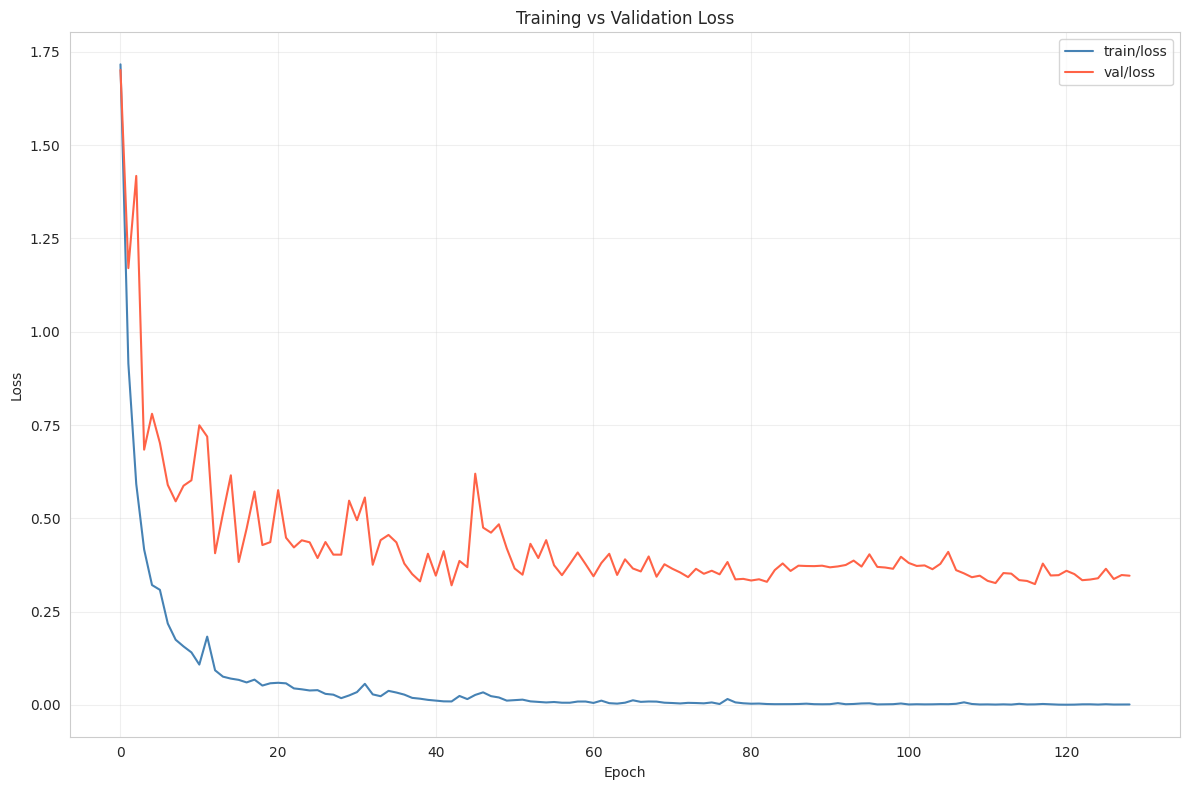

Saved loss curve to /home/lukasb/Documents/NoisyLabelDefectDetection/logs/eval/SurfaceDefectDetection/full_cleaned/loss_curve.png


In [4]:
# Plot training vs validation loss
df = pd.read_csv(METRICS_PATH)
df = df[df["epoch"].notna()].copy()
df["epoch"] = df["epoch"].astype(int)

def last_valid(series: pd.Series):
    non_null = series.dropna()
    return non_null.iloc[-1] if len(non_null) else np.nan

loss_df = df.groupby("epoch").agg({
    "train/loss": last_valid,
    "val/loss": last_valid,
}).reset_index()

fig, ax = plt.subplots()
ax.plot(loss_df["epoch"], loss_df["train/loss"], label="train/loss", color="steelblue")
ax.plot(loss_df["epoch"], loss_df["val/loss"], label="val/loss", color="tomato")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

EVAL_PATH.mkdir(parents=True, exist_ok=True)
loss_plot_path = EVAL_PATH / "loss_curve.png"
fig.savefig(loss_plot_path, dpi=300, bbox_inches="tight")
print(f"Saved loss curve to {loss_plot_path}")

## Load Model and Generate Predictions

In [5]:
def load_model(checkpoint_path: Path):
    model = hydra.utils.instantiate(hyperparams.model)
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
    state = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    model.load_state_dict(state, strict=True)
    model.to(device)
    model.eval()
    print(f"Loaded model from: {checkpoint_path}")
    return model

def get_predictions(model, dataloader):
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            preds = torch.argmax(outputs, dim=1)
            all_preds.append(preds.cpu())
            all_targets.append(targets.cpu())
    return {
        "predictions": torch.cat(all_preds).numpy(),
        "targets": torch.cat(all_targets).numpy(),
    }

model = load_model(CHECKPOINT_PATH)
test_loader = datamodule.test_dataloader()
print("Generating predictions on test set...")
results = get_predictions(model, test_loader)
print(f"Generated predictions for {len(results['predictions'])} samples")

Loaded model from: /home/lukasb/Documents/NoisyLabelDefectDetection/logs/train/SurfaceDefectDetection/full_cleaned/2026-02-10_12-12-03_ce/run_2/checkpoints/epoch_078-val_f1_0.9330.ckpt
Generating predictions on test set...
Generated predictions for 680 samples


## Confusion Matrix

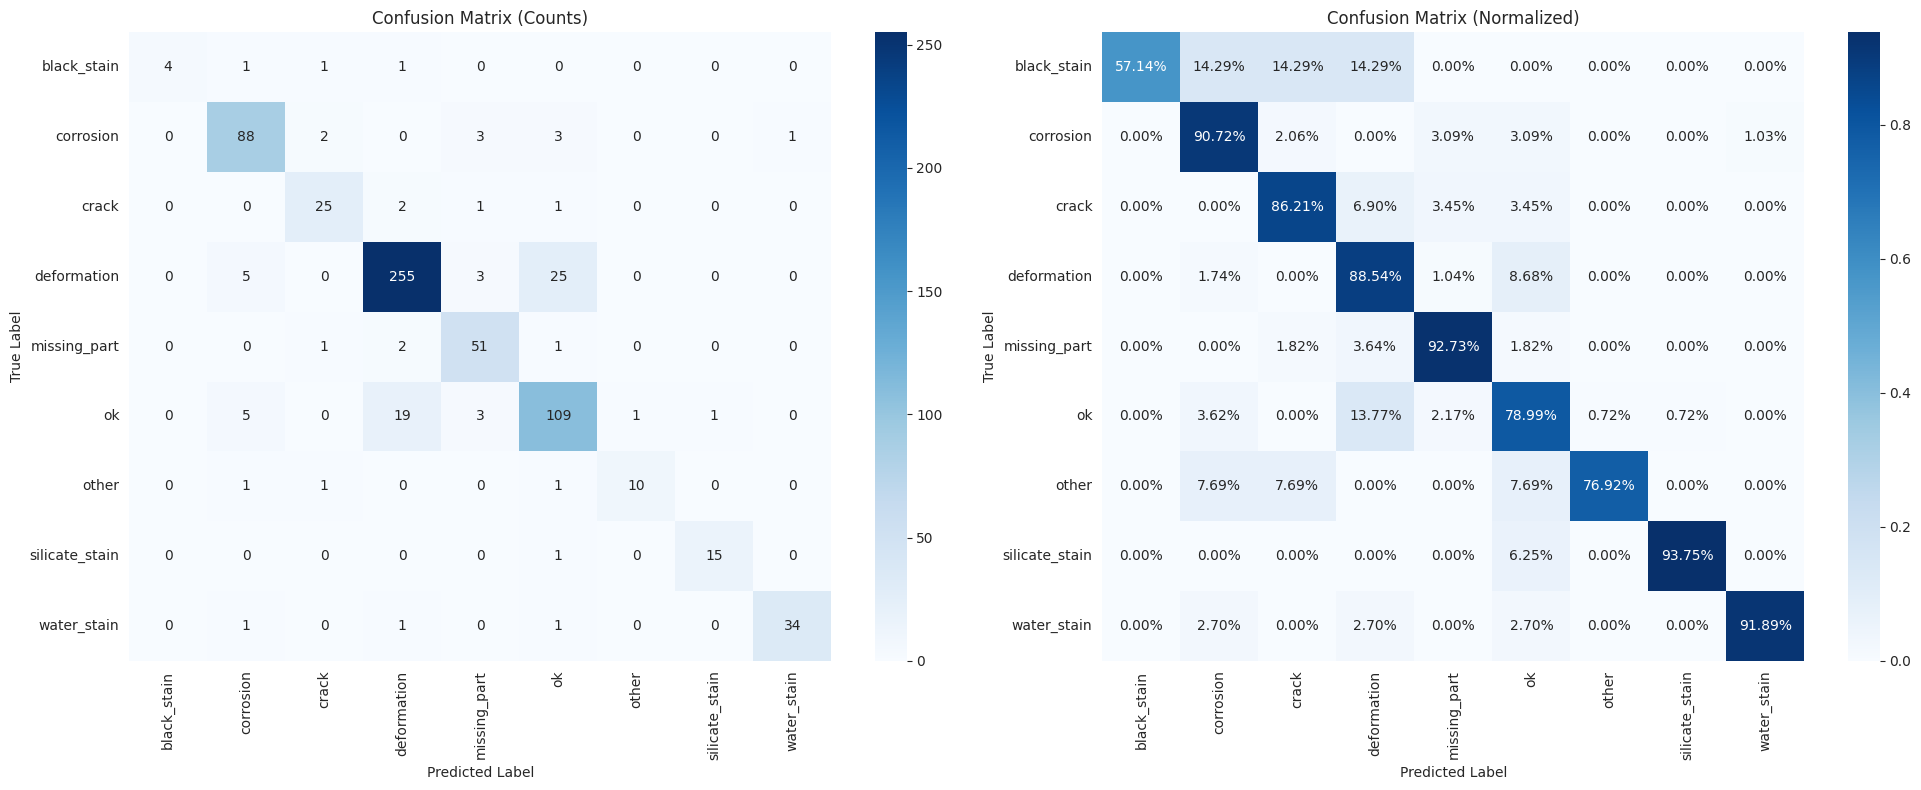

Saved confusion matrix to /home/lukasb/Documents/NoisyLabelDefectDetection/logs/eval/SurfaceDefectDetection/full_cleaned/confusion_matrix.png


In [6]:
targets = results["targets"]
preds = results["predictions"]

cm = confusion_matrix(targets, preds)
cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax1)
ax1.set_title("Confusion Matrix (Counts)")
ax1.set_xlabel("Predicted Label")
ax1.set_ylabel("True Label")

sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax2)
ax2.set_title("Confusion Matrix (Normalized)")
ax2.set_xlabel("Predicted Label")
ax2.set_ylabel("True Label")

plt.tight_layout()
plt.show()

cm_path = EVAL_PATH / "confusion_matrix.png"
fig.savefig(cm_path, dpi=300, bbox_inches="tight")
print(f"Saved confusion matrix to {cm_path}")

## Example Predictions

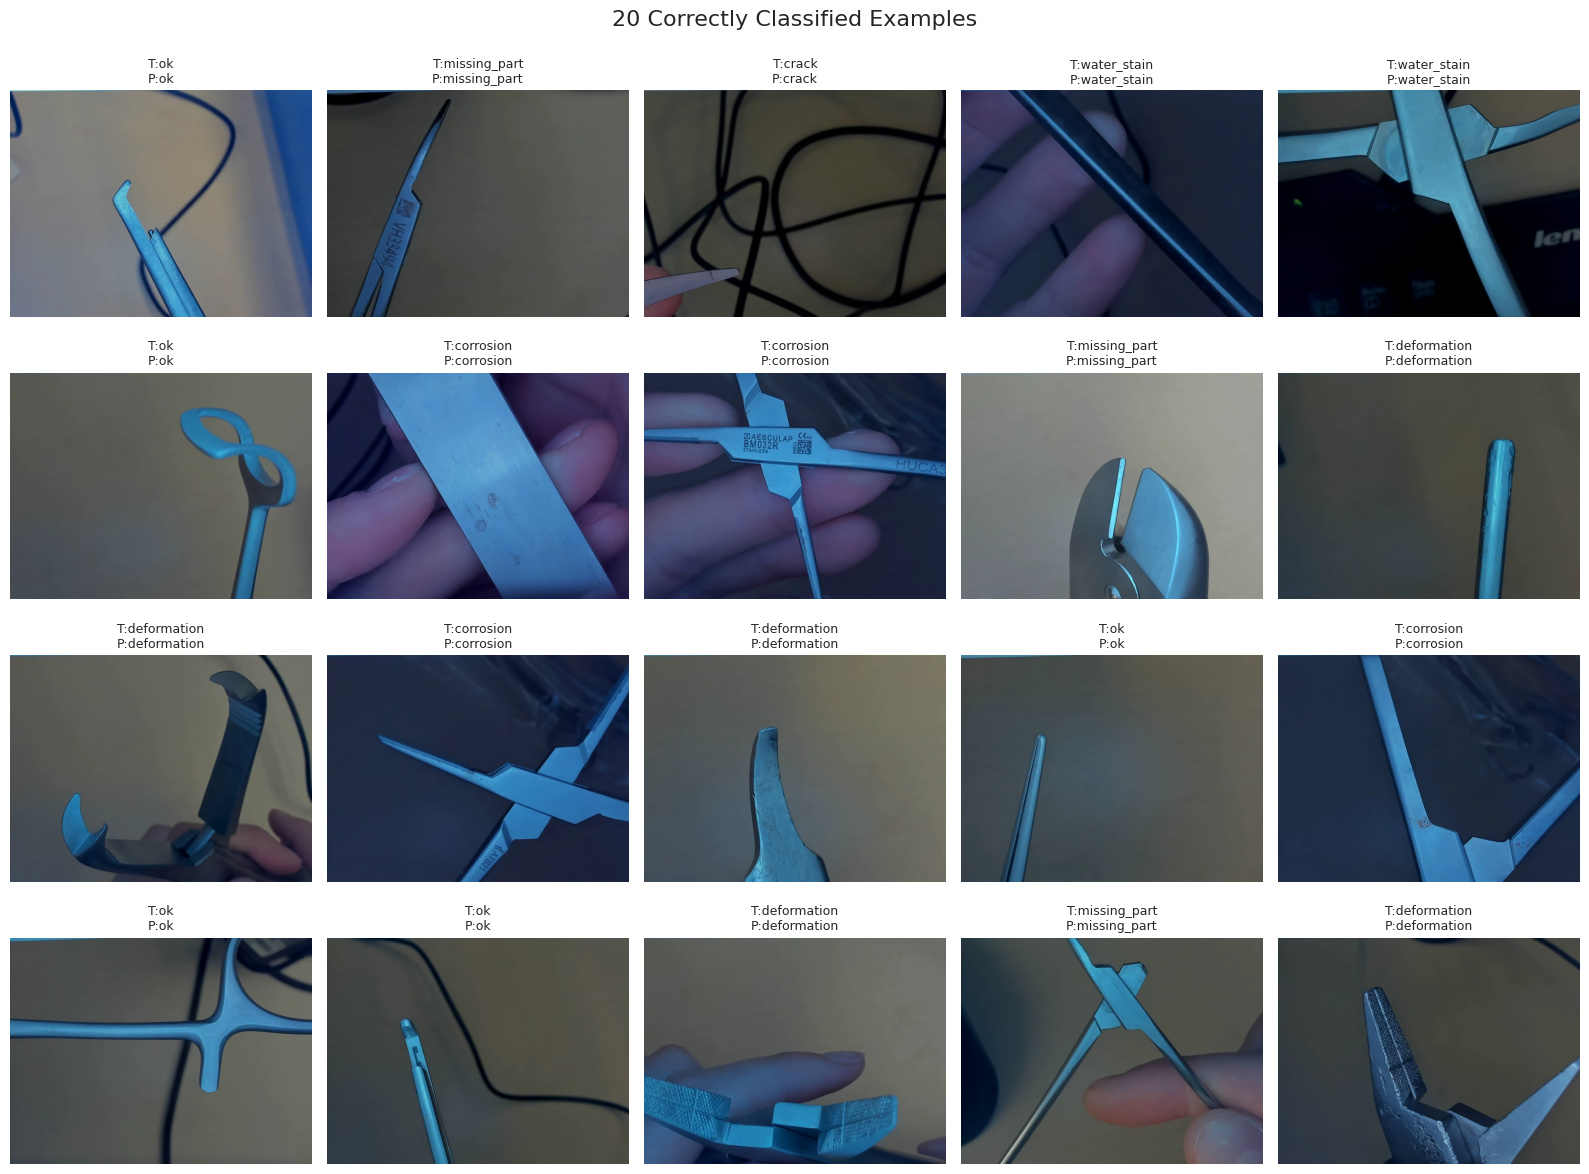

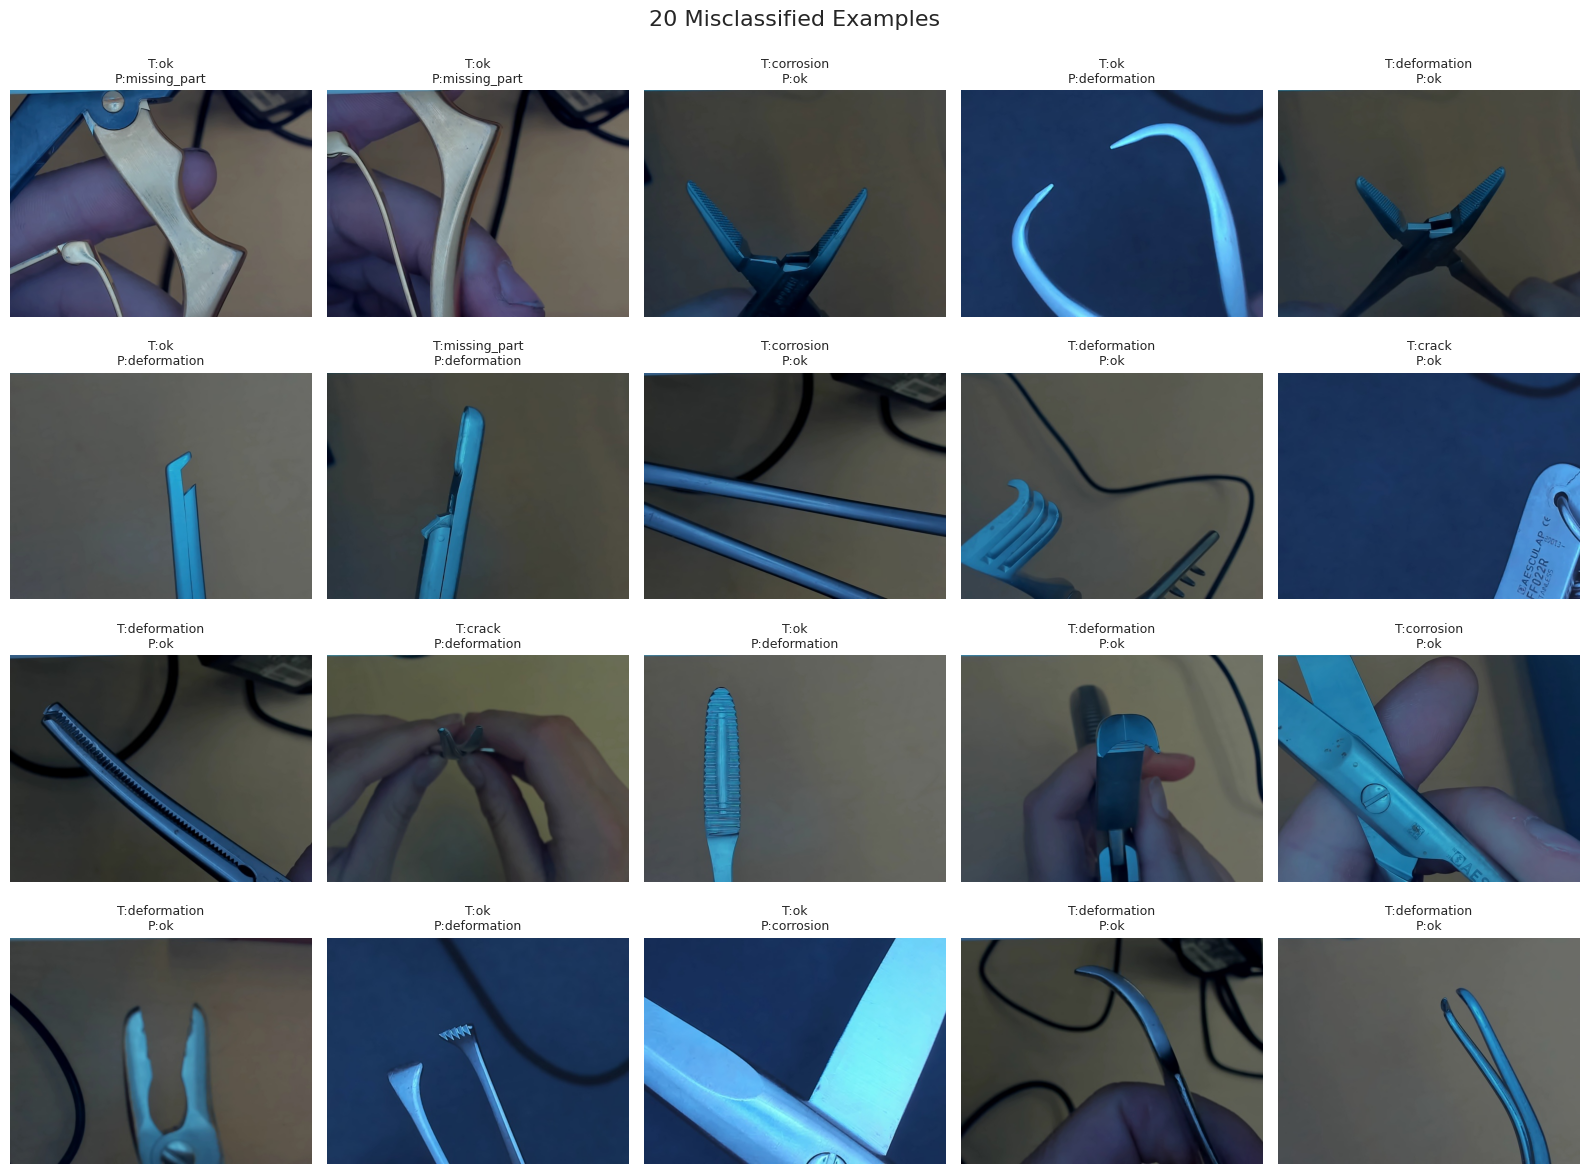

Saved correct examples to /home/lukasb/Documents/NoisyLabelDefectDetection/logs/eval/SurfaceDefectDetection/full_cleaned/examples_correct.png
Saved wrong examples to /home/lukasb/Documents/NoisyLabelDefectDetection/logs/eval/SurfaceDefectDetection/full_cleaned/examples_wrong.png


In [7]:
def get_image_path(dm, index: int) -> str:
    if hasattr(dm, "test_dataset"):
        test_dataset = dm.test_dataset
        if hasattr(test_dataset, "parent") and hasattr(test_dataset, "indices"):
            real_idx = test_dataset.indices[index]
            parent = test_dataset.parent
            if hasattr(parent, "samples"):
                return parent.samples[real_idx][0]
        for attr in ("samples", "imgs"):
            if hasattr(test_dataset, attr):
                return getattr(test_dataset, attr)[index][0]
    if hasattr(dm, "test_ds"):
        test_ds = dm.test_ds
        for attr in ("samples", "imgs"):
            if hasattr(test_ds, attr):
                return getattr(test_ds, attr)[index][0]
    raise AttributeError("Could not find image paths on datamodule/test dataset.")

rng = np.random.default_rng(42)
correct_indices = np.where(preds == targets)[0]
wrong_indices = np.where(preds != targets)[0]

def sample_indices(indices: np.ndarray, n: int) -> np.ndarray:
    if len(indices) <= n:
        return indices
    return rng.choice(indices, size=n, replace=False)

correct_sample = sample_indices(correct_indices, 20)
wrong_sample = sample_indices(wrong_indices, 20)

def show_examples(indices: np.ndarray, title: str):
    n = len(indices)
    fig, axes = plt.subplots(4, 5, figsize=(16, 12))
    axes = axes.ravel()
    for i, idx in enumerate(indices):
        img_path = get_image_path(datamodule, int(idx))
        img = plt.imread(img_path)
        axes[i].imshow(img)
        axes[i].axis("off")
        true_name = class_names[targets[idx]]
        pred_name = class_names[preds[idx]]
        axes[i].set_title(f"T:{true_name}\nP:{pred_name}", fontsize=9)
    for j in range(n, len(axes)):
        axes[j].axis("off")
    plt.suptitle(title, fontsize=16, y=0.995)
    plt.tight_layout()
    plt.show()
    return fig

fig_correct = show_examples(correct_sample, "20 Correctly Classified Examples")
fig_wrong = show_examples(wrong_sample, "20 Misclassified Examples")

correct_path = EVAL_PATH / "examples_correct.png"
wrong_path = EVAL_PATH / "examples_wrong.png"
fig_correct.savefig(correct_path, dpi=300, bbox_inches="tight")
fig_wrong.savefig(wrong_path, dpi=300, bbox_inches="tight")
print(f"Saved correct examples to {correct_path}")
print(f"Saved wrong examples to {wrong_path}")